Server Performance Anomaly Detection using One-Class SVM

First 5 Rows:
   ServerID  CPU_Utilization_Pct  Memory_Utilization_Pct  Disk_IOPS  \
0  SRV-7000                 36.7                    48.7       1173   
1  SRV-7001                 97.3                    62.3       2221   
2  SRV-7002                 30.0                    61.8       1044   
3  SRV-7003                 39.2                    36.6        821   
4  SRV-7004                 39.5                    61.8        953   

   Network_Latency_MS  Active_Thread_Count  Error_Log_Rate_per_Min  
0                14.4                  166                       0  
1               347.0                 1669                      15  
2                15.6                  194                       0  
3                24.0                  221                       0  
4                18.6                  204                       0  

Dataset Shape:
(600, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 colu

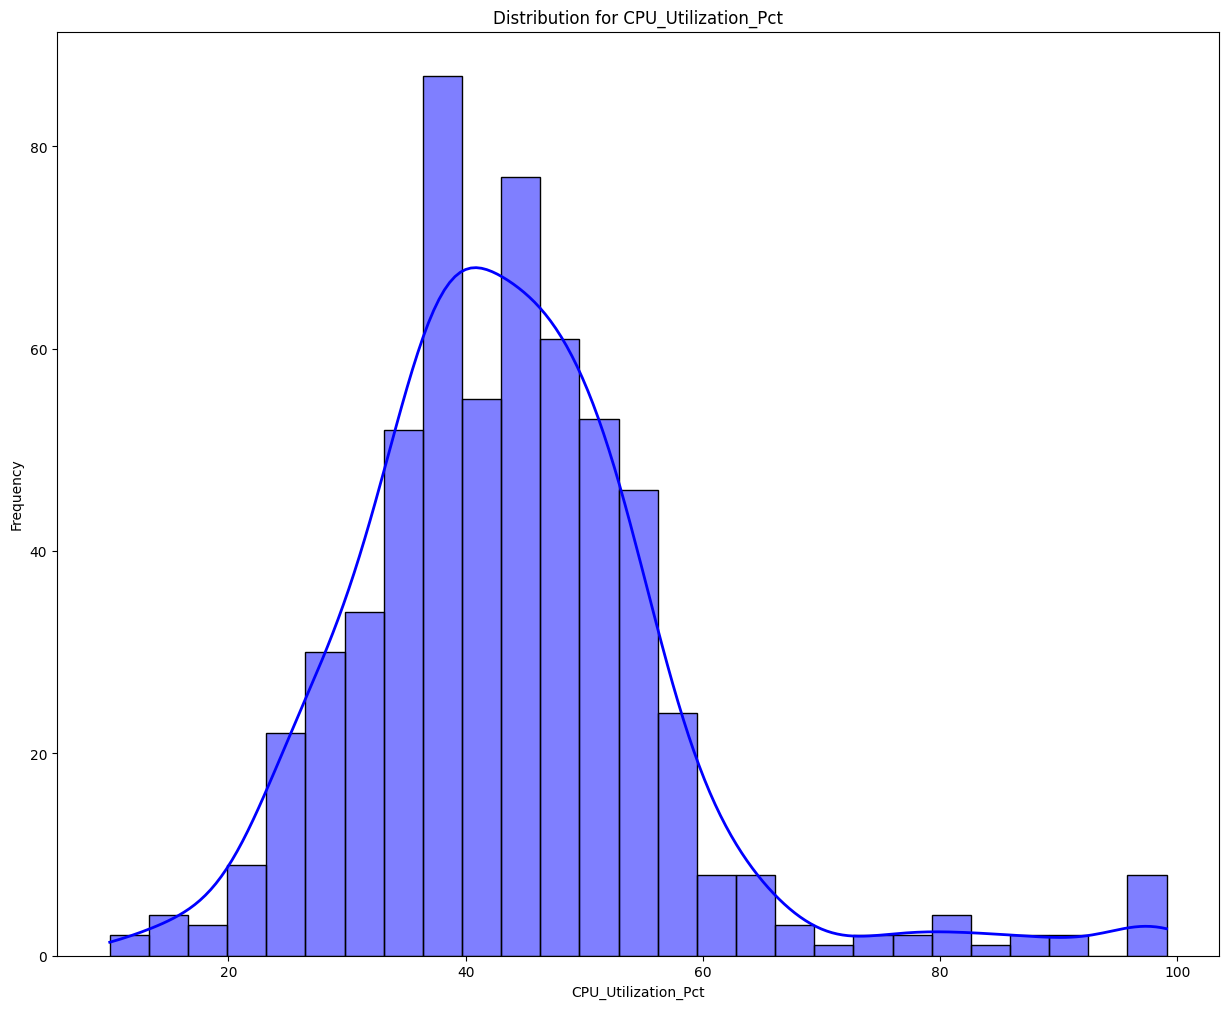

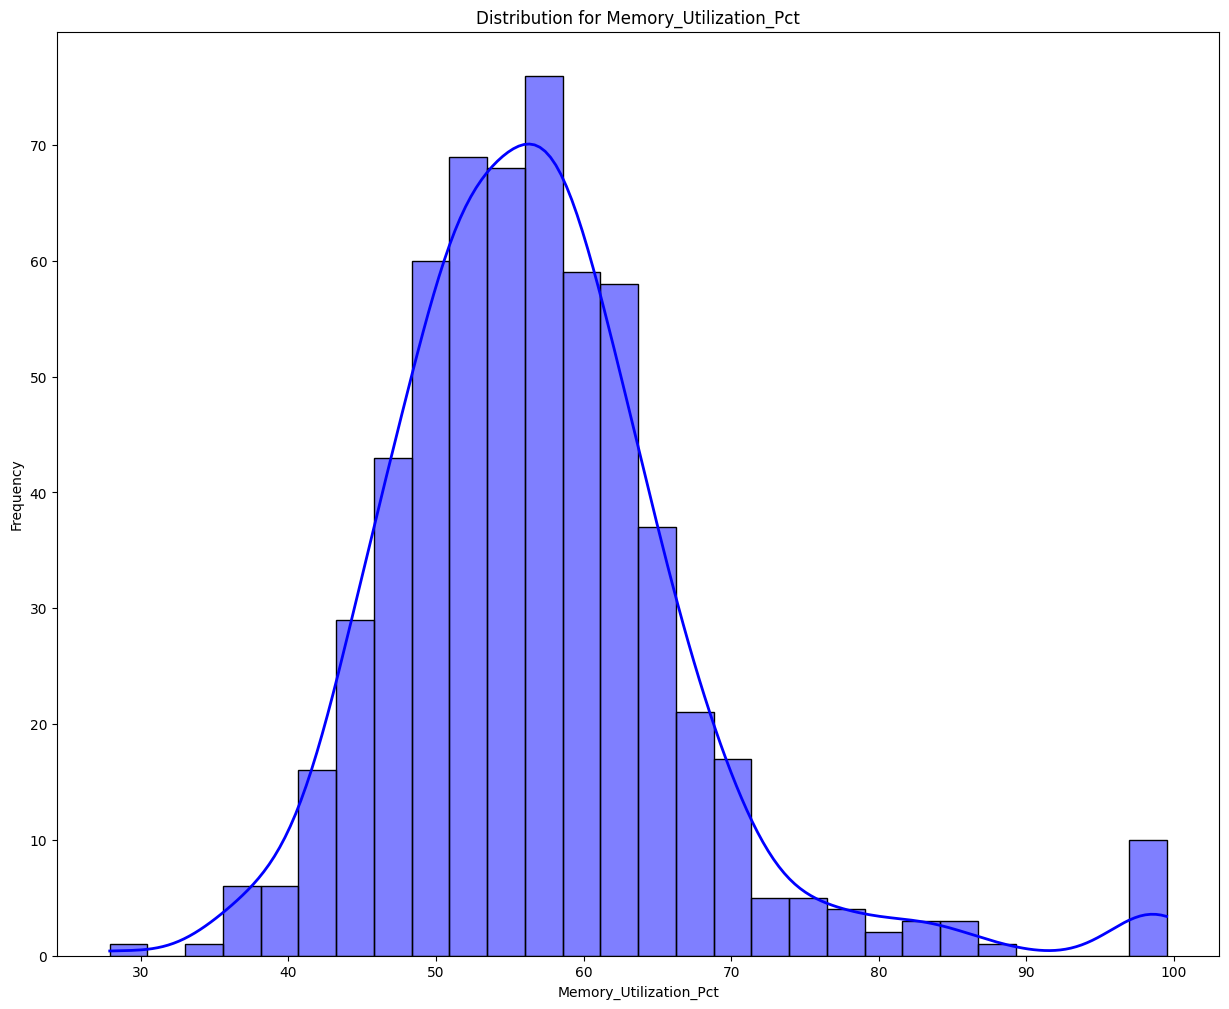

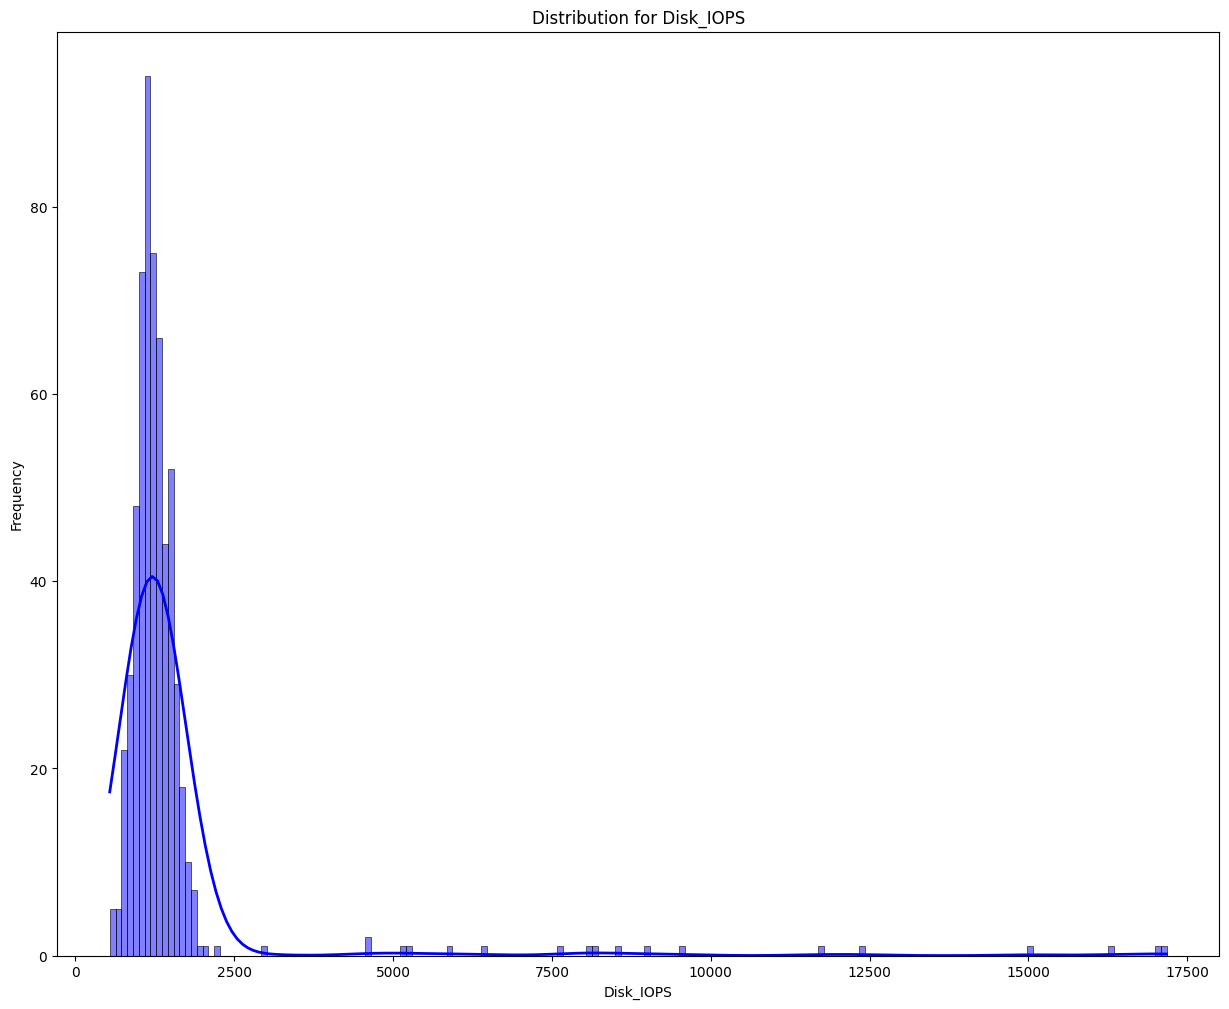

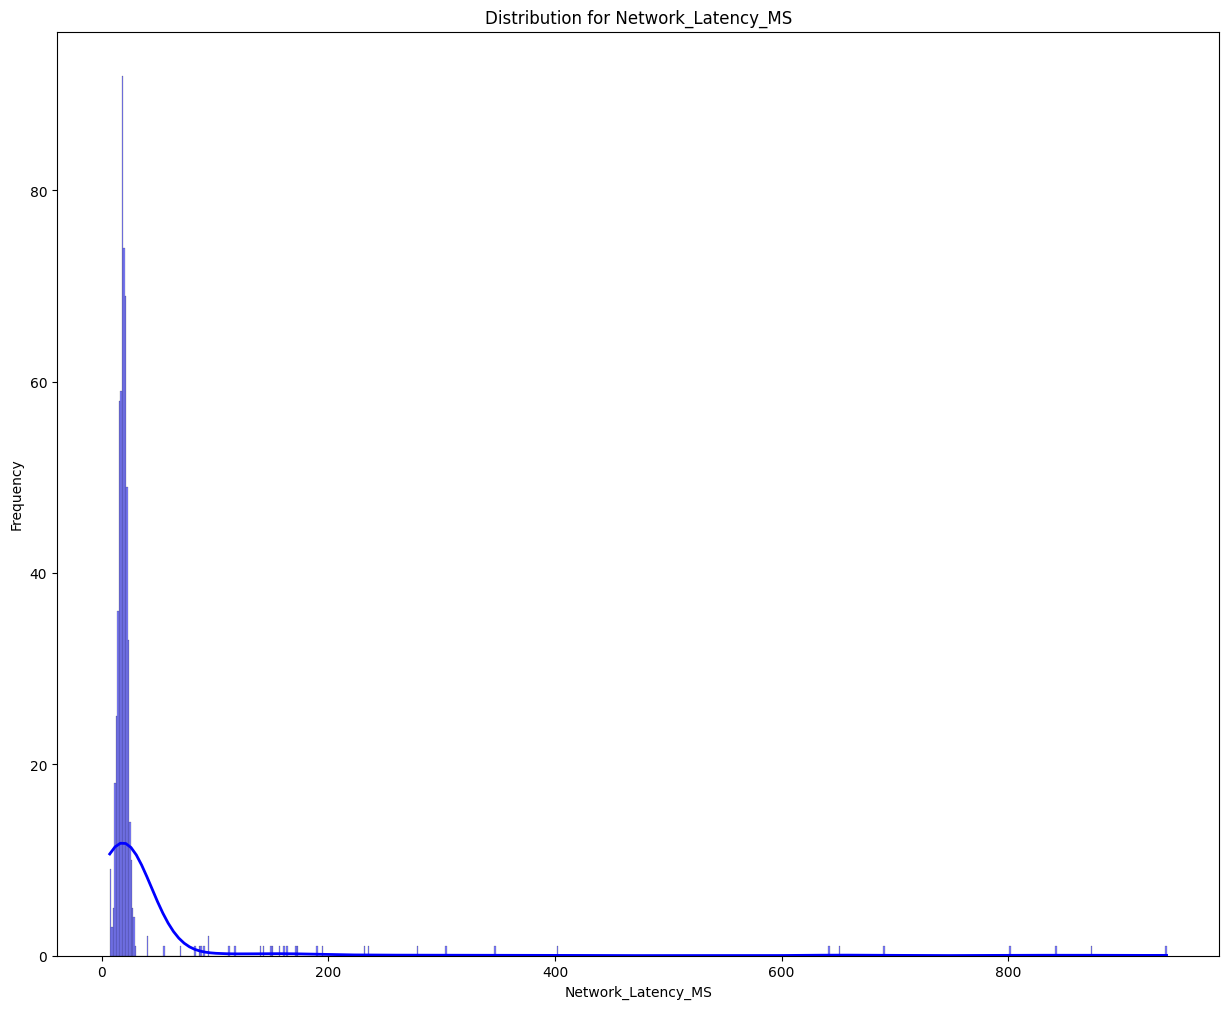

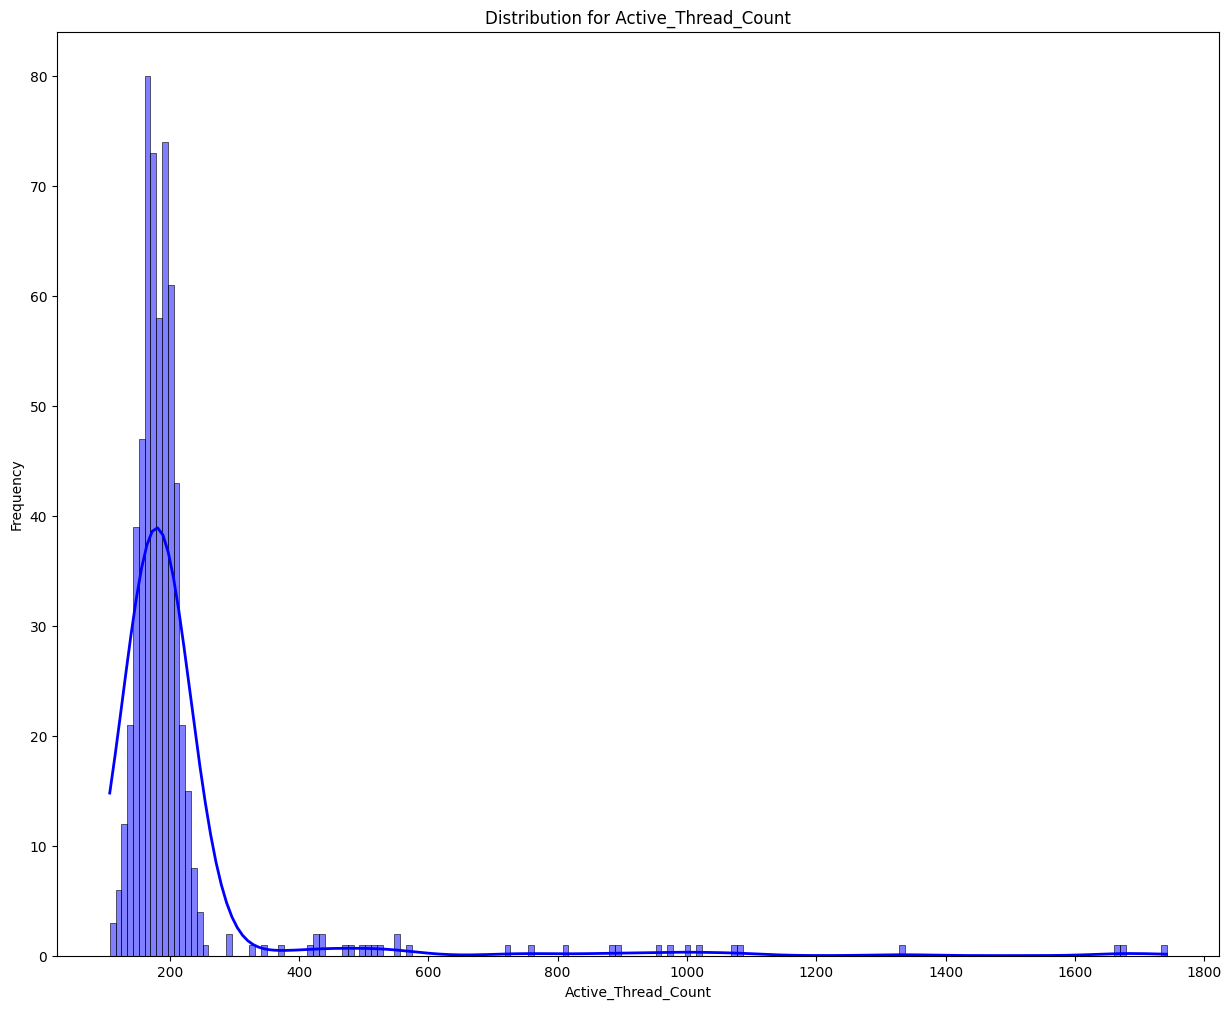

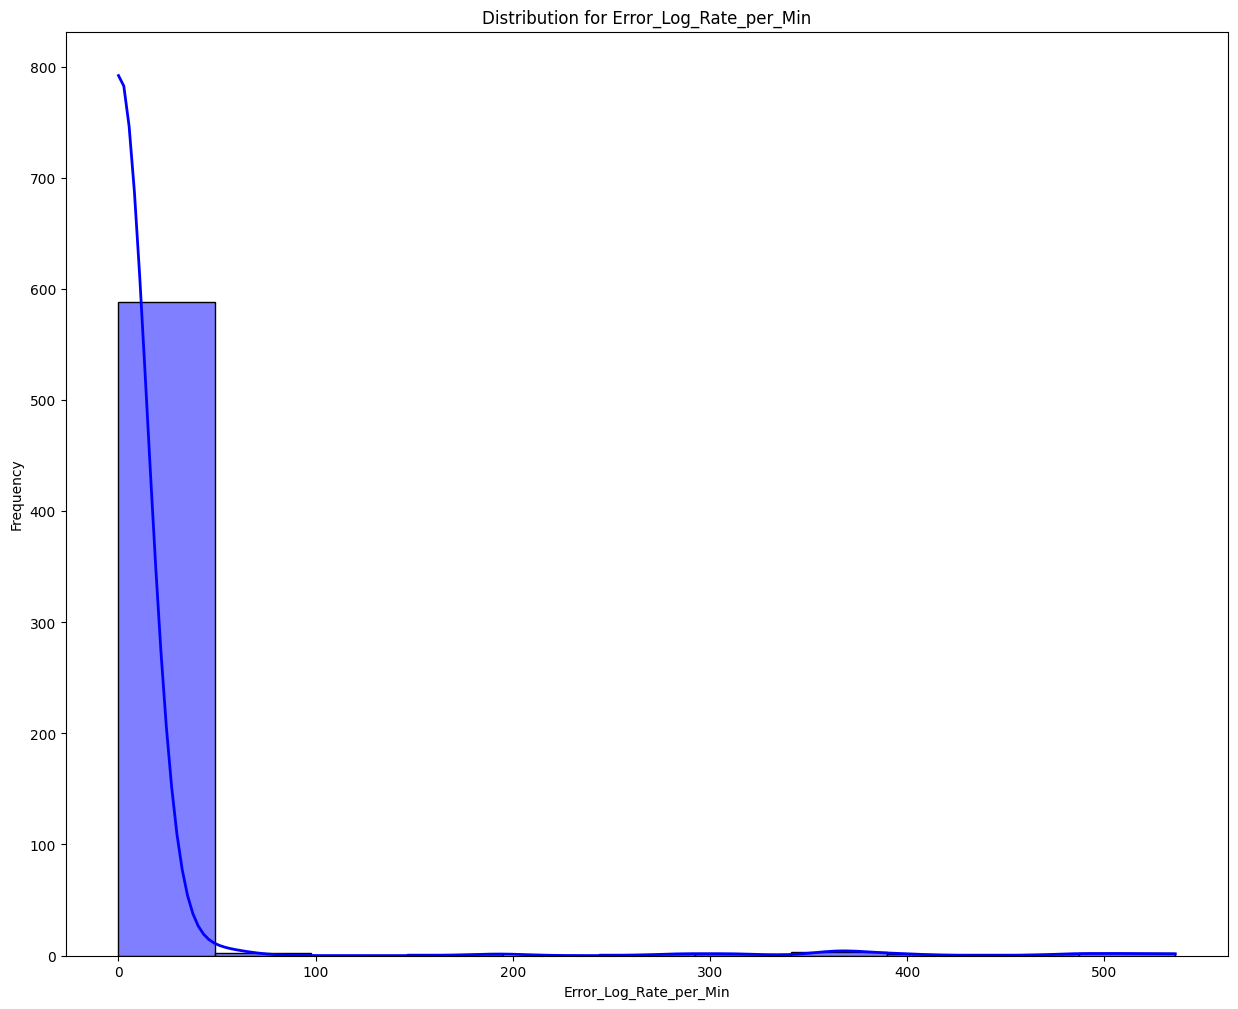

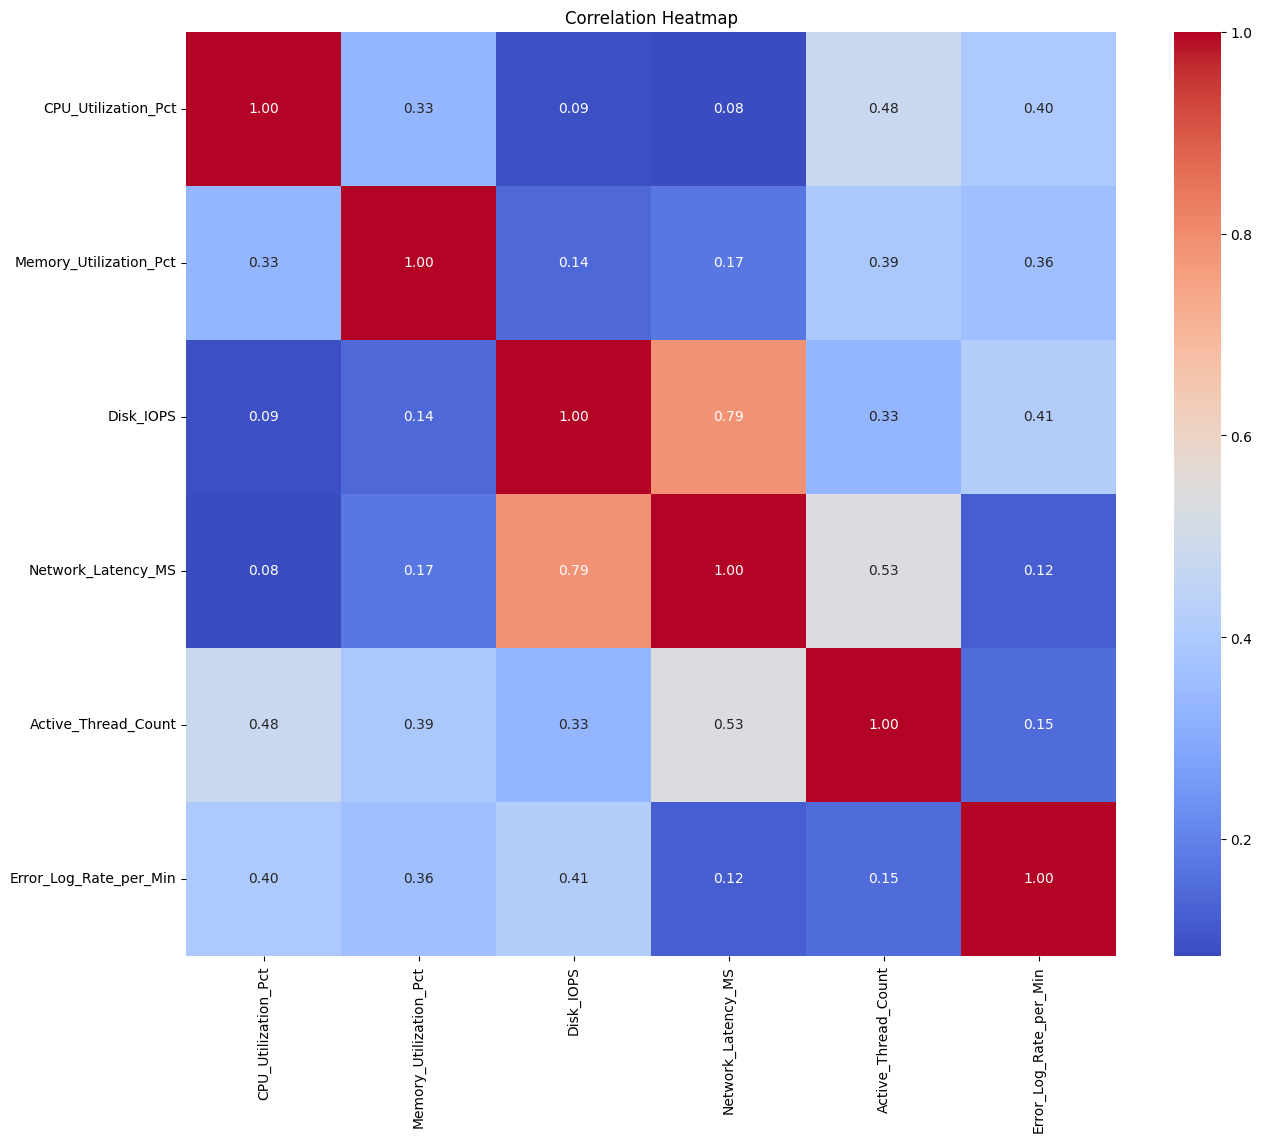


Selected Features:
   CPU_Utilization_Pct  Memory_Utilization_Pct  Disk_IOPS  Network_Latency_MS  \
0                 36.7                    48.7       1173                14.4   
1                 97.3                    62.3       2221               347.0   
2                 30.0                    61.8       1044                15.6   
3                 39.2                    36.6        821                24.0   
4                 39.5                    61.8        953                18.6   

   Active_Thread_Count  Error_Log_Rate_per_Min  
0                  166                       0  
1                 1669                      15  
2                  194                       0  
3                  221                       0  
4                  204                       0  

Scaled Data:
[[-0.53135693 -0.80891265 -0.18749454 -0.22128088 -0.27914762 -0.14781802]
 [ 4.05165333  0.54092932  0.45800119  3.51418514  8.99868097  0.14814687]
 [-1.03805939  0.49130277 -0.266949

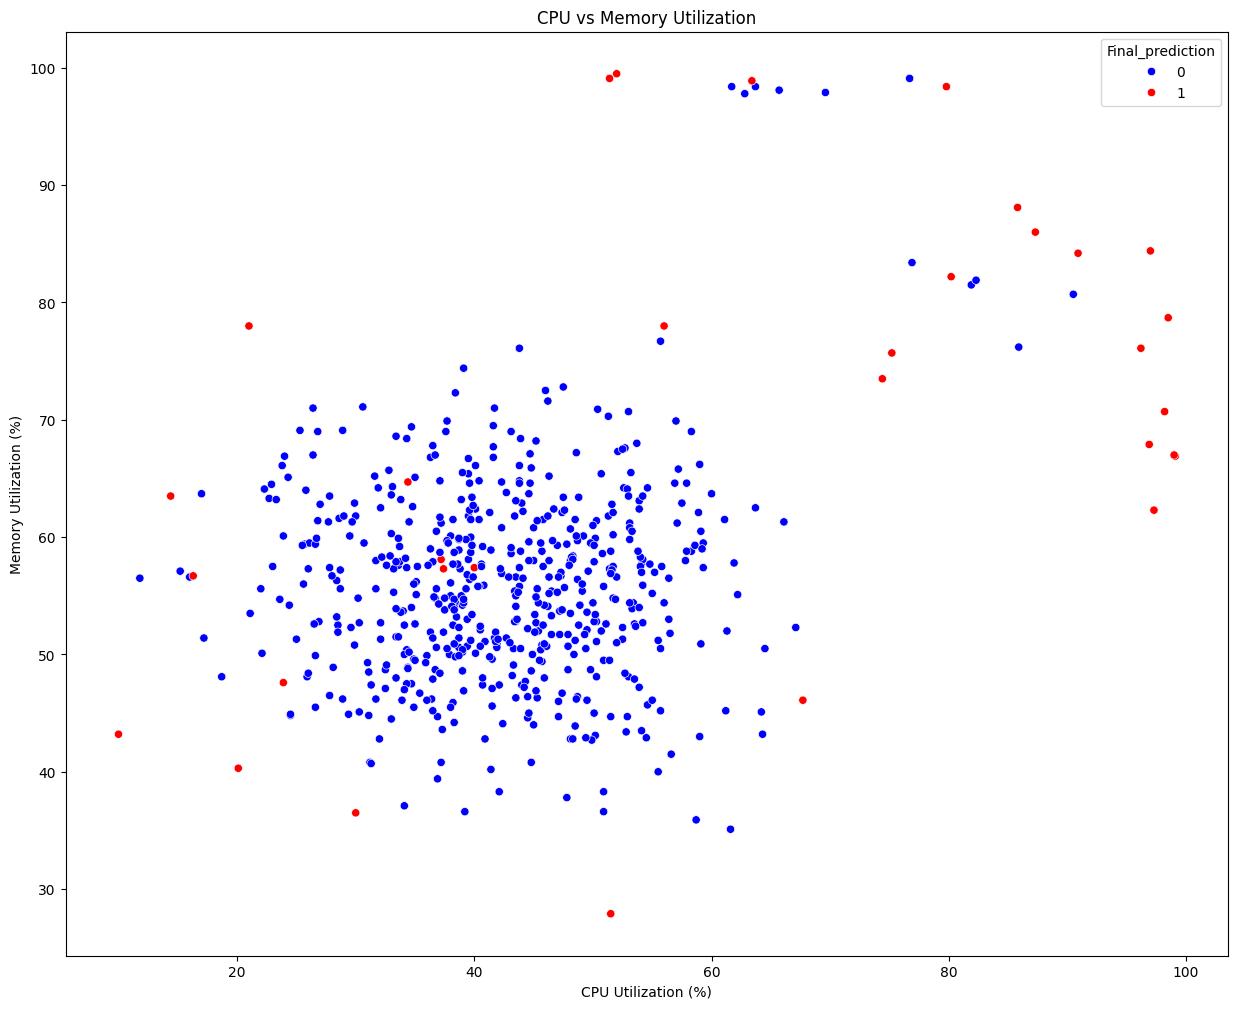

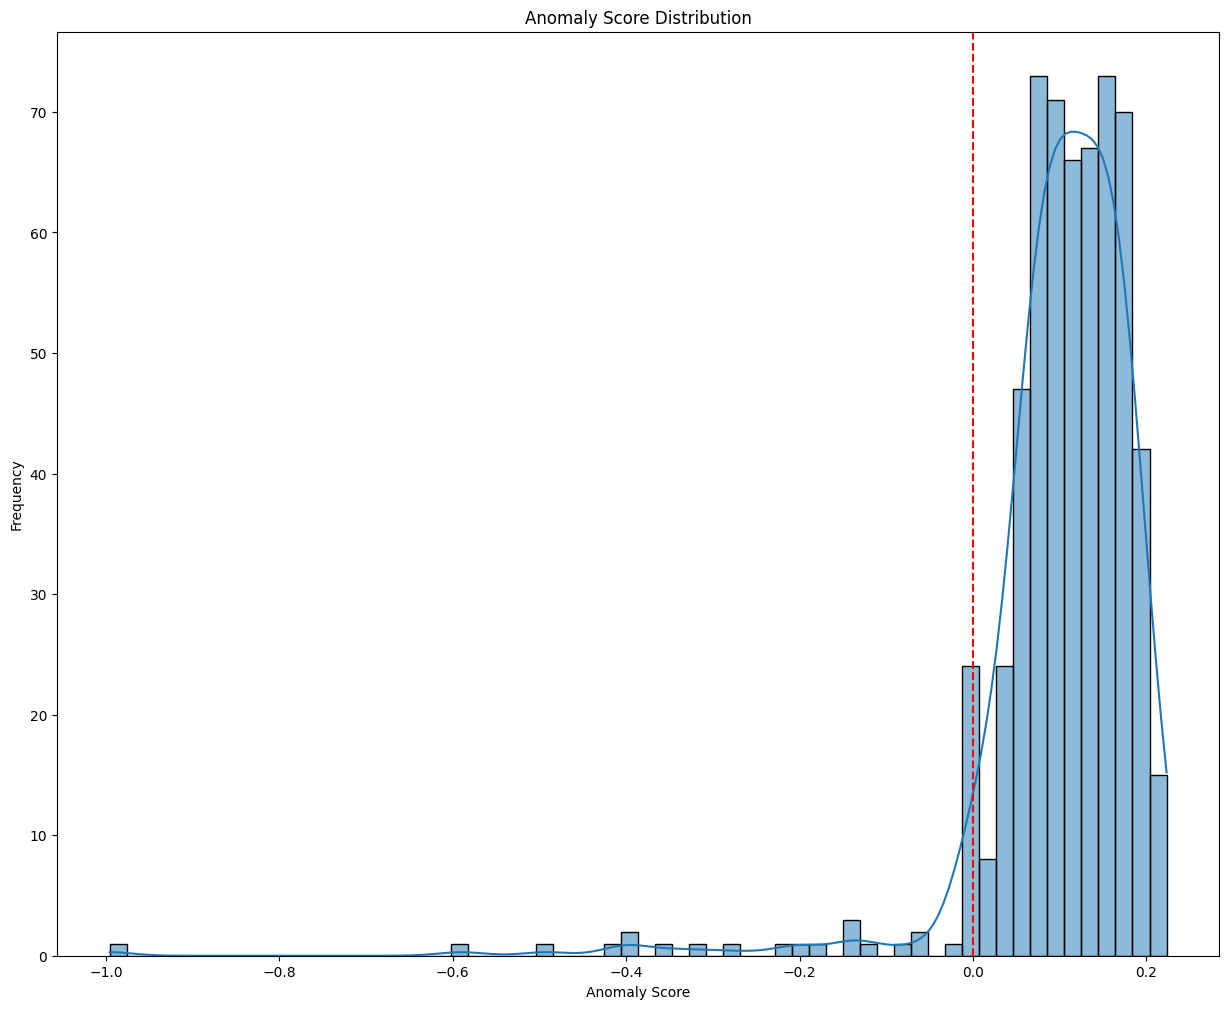

Timestamp column not found in the DataFrame.


In [4]:
# 1. IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import(
    precision_score,
    recall_score,
    f1_score
)


# 2. LOAD DATASET

df = pd.read_csv("/content/server_performance_telemetry.csv")

print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

# 3. CLEAN COLUMN NAMES
df.columns = df.columns.str.strip()

print("\nColumns:")
print(df.columns.tolist())

# 4. CHECK MISSING VALUES
print("\nMissing Values:")
print(df.isnull().sum())

# 5. CHECK DUPLICATES
print("\nDuplicated Rows:")
print(df.duplicated().sum())

# 6. HANDLE INFINITE VALUES
df = df.replace([np.inf, -np.inf], np.nan)

# 7. REMOVE MISSING VALUES

df = df.dropna().reset_index(drop=True)
print("\nShape After Cleaning:")
print(df.shape)


# 8. EDA - DISTRIBUTIONS

features_for_plot = [
    "CPU_Utilization_Pct",
    "Memory_Utilization_Pct",
    "Disk_IOPS",
    "Network_Latency_MS",
    "Active_Thread_Count",
    "Error_Log_Rate_per_Min"
]

for feature in features_for_plot:
  plt.figure(figsize=(15,12))
  sns.histplot(
      data=df,
      x=feature,
      kde=True,
      line_kws={"color":"red", "linewidth":2},
      color="blue",
      edgecolor="black"
  )

  plt.title(f"Distribution for {feature}")
  plt.xlabel(feature)
  plt.ylabel("Frequency")
  plt.savefig(f"Distribution for {feature}.png")
  plt.show()

# 9. CORRELATION HEATMAP
plt.figure(figsize=(15,12))
sns.heatmap(
    df[features_for_plot].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.savefig("Correlation Heatmap.png")
plt.show()

# 10. SELECT FEATURES

X = df[features_for_plot]

print("\nSelected Features:")
print(X.head())

# 11. FEATURE SCALING
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)
print("\nScaled Data:")
print(X_Scaled[:5])

# 12. CREATE REFERENCE LABEL (rule-based anomaly detection)
# Example: flag anomalies if CPU > 90% OR Error_Log_Rate > 50
df["reference_label"] = np.where(
    (df["CPU_Utilization_Pct"] > 90) | (df["Error_Log_Rate_per_Min"] > 50),
    1,  # anomaly
    0   # normal
)

print("\nReference Label Counts:")
print(df["reference_label"].value_counts())

# 13. BASELINE ONE-CLASS SVM
baseline_model = OneClassSVM(
    kernel="rbf",
    gamma = "scale",
    nu = 0.05
)

baseline_prediction = baseline_model.fit_predict(X_Scaled)

# 14. BASELINE PREDICTIONS
df["Baseline_Prediction"] = baseline_prediction

df["Baseline_Anomaly"] = np.where(
    df["Baseline_Prediction"] == -1,
    1,
    0
)

print("\nBaseline Prediction Count:")
print(df["Baseline_Prediction"].value_counts())

print("\nBaseline Anomaly Count:")
print(df["Baseline_Anomaly"].value_counts())

# 15. BASELINE ANOMALY SCORE
baseline_scores = baseline_model.decision_function(X_Scaled)
df["Baseline_Score"] = baseline_scores
print(df[ ["Baseline_Prediction", "Baseline_Score"] ].head(10))

# 16. BASELINE ANOMALIES
baseline_anomalies = df[
    df["Baseline_Anomaly"] == 1
]

print("\nBaseline Anomalies:")
print(baseline_anomalies[
    features_for_plot + ["Baseline_Score"]
].head(20))

# 17. PARAMETER TUNING
nu_values = [
    0.01,
    0.03,
    0.05,
    0.10,
    0.20
]

gamma_values = [
    "scale",
    0.001,
    0.01,
    0.1,
    1
]

result = []

# 18. TEST EVERY PARAMETER COMBINATION

for nu in nu_values:
  for gamma in gamma_values:

    temp_model = OneClassSVM(
        kernel = "rbf",
        nu = nu,
        gamma = gamma
    )

    predictions = temp_model.fit_predict(X_Scaled)
    temp_preds_binary = np.where(
        predictions == -1,
        1,
        0
    )

    df["predictions"] = temp_preds_binary

    precision = precision_score(
        df["reference_label"],
        df["predictions"]
    )

    recall = recall_score(
        df["reference_label"],
        df["predictions"]
    )

    f1 = f1_score(
        df["reference_label"],
        df["predictions"]
    )

    anomaly_count = np.sum(
        predictions == -1
    )

    normal_count = np.sum(
        predictions == 1
    )

    anomaly_percentage = (
        anomaly_count / len(predictions)
    )

    result.append(
        {
            "Nu": nu,
            "Gamma": gamma,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Model": "One-Class SVM",
            "Anomaly Count": anomaly_count,
            "Normal Count": normal_count,
            "Anomaly Percentage": anomaly_percentage
        }
    )


# 19. CREATE RESULTS TABLE

results_df = pd.DataFrame(result)
print("\nParameter Tuning Results:")
print(results_df)

# 20. SORT RESULTS
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\nSorted Results:")
print(results_df)

print("\nParameter Tuining Completed")

# 21. SELECT FINAL PARAMETERS

best_row = results_df.iloc[0]
best_nu = best_row["Nu"]
best_gamma = best_row["Gamma"]

print(f"\nBest Nu: {best_nu}")
print(f"Best Gamma: {best_gamma}")

print(f"\nBest Parameters → Nu: {best_nu}, Gamma: {best_gamma}")

# 22. TRAIN FINAL MODEL
final_model = OneClassSVM(
    kernel = "rbf",
    nu = best_nu,
    gamma = best_gamma
)

final_pred = final_model.fit_predict(X_Scaled)


df["Final_prediction"] = np.where(
    final_pred == -1,
    1,
    0
)

print("\nFinal Prediction Count:")
print(df["Final_prediction"].value_counts())

# 23: FINAL ANOMALY SCORE
Final_Score = final_model.decision_function(X_Scaled)
df["Final_Score"] = Final_Score
print(df[["Final_prediction", "Final_Score"]].head(10))



# 24. FINAL ANOMALY PERCENTAGE

final_anomaly_count = np.sum(final_pred == -1)
final_normal_count = np.sum(final_pred == 1)

final_anomaly_percentage = (
    final_anomaly_count / len(final_pred)
)*100

print("\nFinal Anomaly Count:", final_anomaly_count)
print("Final Normal Count:", final_normal_count)
print("Final Anomaly Percentage:", final_anomaly_percentage)

final_precision = precision_score(df["reference_label"], df["Final_prediction"], zero_division=0)
final_recall = recall_score(df["reference_label"], df["Final_prediction"], zero_division=0)
final_f1 = f1_score(df["reference_label"], df["Final_prediction"], zero_division=0)

print(f"\nFinal Precision: {final_precision:.3f}")
print(f"Final Recall: {final_recall:.3f}")
print(f"Final F1 Score: {final_f1:.3f}")

# 25. DISPLAY DETECTED ANOMALIES

final_anomalies = df[df["Final_prediction"] == 1]
print("\nDetected Anomalies:")
print(final_anomalies[features_for_plot + ["Final_Score"]].head(20))

# 26. VISUALIZATION CPU vs MEMORY
plt.figure(figsize=(15,12))
sns.scatterplot(
    data=df,
    x="CPU_Utilization_Pct",
    y="Memory_Utilization_Pct",
    hue="Final_prediction",
    palette=["blue", "red"],
)
plt.title("CPU vs Memory Utilization")
plt.xlabel("CPU Utilization (%)")
plt.ylabel("Memory Utilization (%)")
plt.savefig("CPU vs Memory Utilization.png")
plt.show()

# 27. ANOMALY SCORE DISTRIBUTION

plt.figure(figsize=(15,12))
sns.histplot(
    df["Final_Score"],
    kde=True
)
plt.axvline(
    0,
    color="red",
    linestyle="--"
)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.savefig("Anomaly Score Distribution")
plt.show()

# 38. ANOMALIES OVER TIME

if "Timestamp" in df.columns:
  df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
  df.set_index("Timestamp", inplace=True)

  plt.figure(figsize=(15,12))

  sns.scatterplot(
      data=df,
      x=df.index,
      y="Final_Score",
      hue="Final_prediction",
      palette=["blue", "red"],
      alpha=0.5
  )
  plt.title("Server CPU Usage - Detected Anomalies")
  plt.xlabel("Timestamp")
  plt.ylabel("Anomaly Score")
  plt.show()
else:
  print("Timestamp column not found in the DataFrame.")